In [ ]:
from matplotlib import pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns

In [ ]:
# Read the main data
flight_df = pd.read_csv('Airline_Delay_Cause.csv')
flight_df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2025,4,HA,Hawaiian Airlines Network,SEA,"Seattle, WA: Seattle/Tacoma International",109.0,44.0,41.12,0.07,...,1.00,1.82,0.0,0.0,1531.0,1462.0,2.0,0.0,28.0,39.0
1,2025,4,NK,Spirit Airlines,SEA,"Seattle, WA: Seattle/Tacoma International",62.0,9.0,1.62,0.00,...,0.64,2.97,1.0,0.0,701.0,379.0,0.0,76.0,14.0,232.0
2,2025,4,OO,SkyWest Airlines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",2226.0,245.0,151.53,19.51,...,0.00,39.17,0.0,0.0,11529.0,7543.0,892.0,1245.0,0.0,1849.0
3,2025,4,QX,Horizon Air,SEA,"Seattle, WA: Seattle/Tacoma International",1719.0,254.0,43.80,0.00,...,0.00,89.49,7.0,0.0,9997.0,2621.0,0.0,3128.0,0.0,4248.0
4,2025,4,AA,American Airlines Network,SEA,"Seattle, WA: Seattle/Tacoma International",450.0,95.0,45.56,7.96,...,0.00,27.74,6.0,0.0,6490.0,2670.0,754.0,542.0,0.0,2524.0


In [ ]:
# Look at the column defintions since it was provided as a separate file
col_def = pd.read_excel('Column_Definitions.xlsx')
col_def

,Column Name,Column Definition
0,year,YYYY format
1,month,MM format (1-12)
2,carrier,Code assigned by assigned by US DOT to identif...
3,carrier_name,Unique airline (carrier) is defined as one hol...
4,airport,A three character alpha-numeric code issued by...
5,airport_name,a place from which aircraft operate that usual...
6,arr_flights,Arrival Flights
7,arr_del15,"Arrival Delay Indicator, 15 Minutes or More Ar..."
8,carrier_ct,Carrier Count for airline cause of delay
9,weather_ct,Weather Count for airline cause of delay


In [ ]:
# Look to see if the carrier name is consistent, turns out it isn't, so there
# needs to be some data scrubbing
carrier_df = flight_df[['carrier', 'carrier_name']]
pd.pivot_table(carrier_df, index=['carrier','carrier_name'], aggfunc='size')

carrier  carrier_name               
AA       American Airlines Inc.         175
         American Airlines Network       88
AS       Alaska Airlines Inc.           175
         Alaska Airlines Network         88
B6       JetBlue Airways                263
CO       Continental Air Lines Inc.     103
CP       Compass Airlines                28
DH       Independence Air                 7
DL       Delta Air Lines Inc.           175
         Delta Air Lines Network         88
EV       Atlantic Southeast Airlines      7
F9       Frontier Airlines               88
         Frontier Airlines Inc.         152
FL       AirTran Airways Corporation     60
HA       Hawaiian Airlines Inc.         170
         Hawaiian Airlines Network       86
HP       America West Airlines Inc.      31
MQ       Envoy Air                       17
NK       Spirit Air Lines                22
         Spirit Airlines                 88
NW       Northwest Airlines Inc.         79
OH       Comair Inc.                      3
OO       SkyWest Airlines Inc.          263
QX       Horizon Air                     88
TZ       ATA Airlines d/b/a ATA          23
UA       United Air Lines Inc.          175
         United Air Lines Network        88
US       US Airways Inc.                145
VX       Virgin America                  75
WN       Southwest Airlines              88
         Southwest Airlines Co.         175
XE       ExpressJet Airlines Inc.        16
YV       Mesa Airlines Inc.              20
YX       Republic Airline                 2
dtype: int64

In [ ]:
carrier_counts = flight_df.groupby(
    ['carrier','carrier_name']).size().reset_index(name='count')

In [ ]:
target_names = {}
for carrier in carrier_counts['carrier'].unique():
    # Get the counts for the current carrier
    names_for_carrier = carrier_counts[carrier_counts['carrier'] == carrier]
    # If the carrier has more than one name
    if len(names_for_carrier) > 1:
        # Find the name with the maximum count
        target_info = names_for_carrier.loc[names_for_carrier['count'].idxmax()]
        target_names[carrier] = {'name': target_info['carrier_name'],
                                 'count': target_info['count']}
# Display the target names for carriers with multiple names
display(target_names)

{'AA': {'name': 'American Airlines Inc.', 'count': np.int64(175)},
 'AS': {'name': 'Alaska Airlines Inc.', 'count': np.int64(175)},
 'DL': {'name': 'Delta Air Lines Inc.', 'count': np.int64(175)},
 'F9': {'name': 'Frontier Airlines Inc.', 'count': np.int64(152)},
 'HA': {'name': 'Hawaiian Airlines Inc.', 'count': np.int64(170)},
 'NK': {'name': 'Spirit Airlines', 'count': np.int64(88)},
 'UA': {'name': 'United Air Lines Inc.', 'count': np.int64(175)},
 'WN': {'name': 'Southwest Airlines Co.', 'count': np.int64(175)}}

In [ ]:
renaming_map = {}
for carrier, target_info in target_names.items():
    # Get all names for the current carrier
    all_names = carrier_counts[carrier_counts['carrier']
                               == carrier]['carrier_name'].tolist()
    # The target name is the one with the highest count
    target_name = target_info['name']
    # Add the other names to the renaming map, mapping them to the target name
    for name in all_names:
        if name != target_name:
            renaming_map[name] = target_name
# Display the renaming map
display(renaming_map)

{'American Airlines Network': 'American Airlines Inc.',
 'Alaska Airlines Network': 'Alaska Airlines Inc.',
 'Delta Air Lines Network': 'Delta Air Lines Inc.',
 'Frontier Airlines': 'Frontier Airlines Inc.',
 'Hawaiian Airlines Network': 'Hawaiian Airlines Inc.',
 'Spirit Air Lines': 'Spirit Airlines',
 'United Air Lines Network': 'United Air Lines Inc.',
 'Southwest Airlines': 'Southwest Airlines Co.'}

In [ ]:
flight_df['carrier_name'] = flight_df['carrier_name'].replace(renaming_map)

In [ ]:
# Now the names are cleaned up, whereas there's minor variations previously
carrier_counts_after_renaming = flight_df.groupby(
    ['carrier','carrier_name']).size().reset_index(name='count')
display(carrier_counts_after_renaming)

,carrier,carrier_name,count
0,AA,American Airlines Inc.,263
1,AS,Alaska Airlines Inc.,263
2,B6,JetBlue Airways,263
3,CO,Continental Air Lines Inc.,103
4,CP,Compass Airlines,28
5,DH,Independence Air,7
6,DL,Delta Air Lines Inc.,263
7,EV,Atlantic Southeast Airlines,7
8,F9,Frontier Airlines Inc.,240
9,FL,AirTran Airways Corporation,60


In [ ]:
# Create a new column called month year and convert it to datetime format
flight_df['month_year'] = pd.to_datetime(
    flight_df['year'].astype(str) + '-' + flight_df['month'].astype(str),
    format='%Y-%m')
# Create a new column called delay percentage
flight_df['delay_percentage'] = round(flight_df['arr_del15'] /
                                      flight_df['arr_flights'], 4) * 100.0
flight_df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,month_year,delay_percentage
0,2025,4,HA,Hawaiian Airlines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",109.0,44.0,41.12,0.07,...,0.0,0.0,1531.0,1462.0,2.0,0.0,28.0,39.0,2025-04-01,40.37
1,2025,4,NK,Spirit Airlines,SEA,"Seattle, WA: Seattle/Tacoma International",62.0,9.0,1.62,0.00,...,1.0,0.0,701.0,379.0,0.0,76.0,14.0,232.0,2025-04-01,14.52
2,2025,4,OO,SkyWest Airlines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",2226.0,245.0,151.53,19.51,...,0.0,0.0,11529.0,7543.0,892.0,1245.0,0.0,1849.0,2025-04-01,11.01
3,2025,4,QX,Horizon Air,SEA,"Seattle, WA: Seattle/Tacoma International",1719.0,254.0,43.80,0.00,...,7.0,0.0,9997.0,2621.0,0.0,3128.0,0.0,4248.0,2025-04-01,14.78
4,2025,4,AA,American Airlines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",450.0,95.0,45.56,7.96,...,6.0,0.0,6490.0,2670.0,754.0,542.0,0.0,2524.0,2025-04-01,21.11


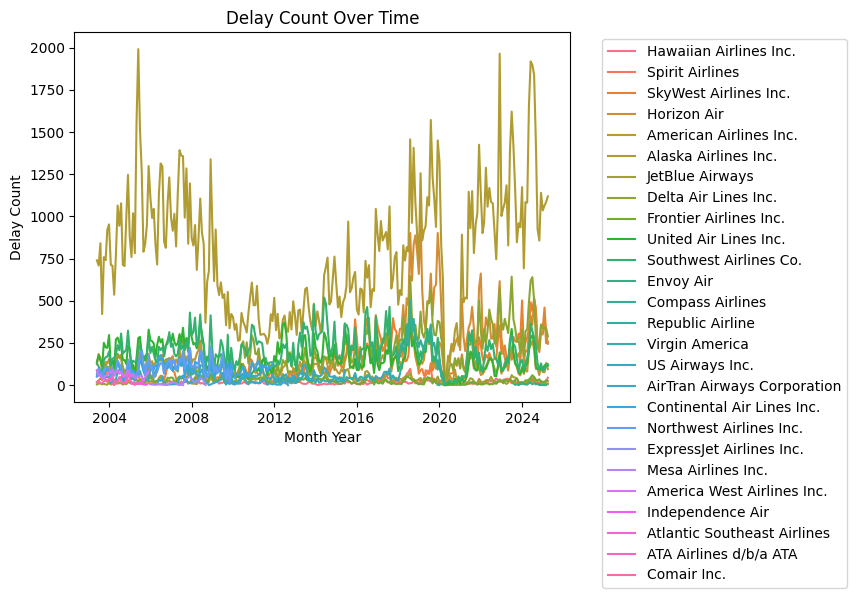

In [ ]:
# Plot delay count over time
sns.lineplot(data=flight_df, x='month_year', y='arr_del15',
             hue = 'carrier_name')
plt.title('Delay Count Over Time')
plt.xlabel('Month Year')
plt.ylabel('Delay Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

From this line graph, it appears that Alaksa Airlines isn't great given they have the largest count of delays compared to other carriers, but they could also have a larger volume of flights.

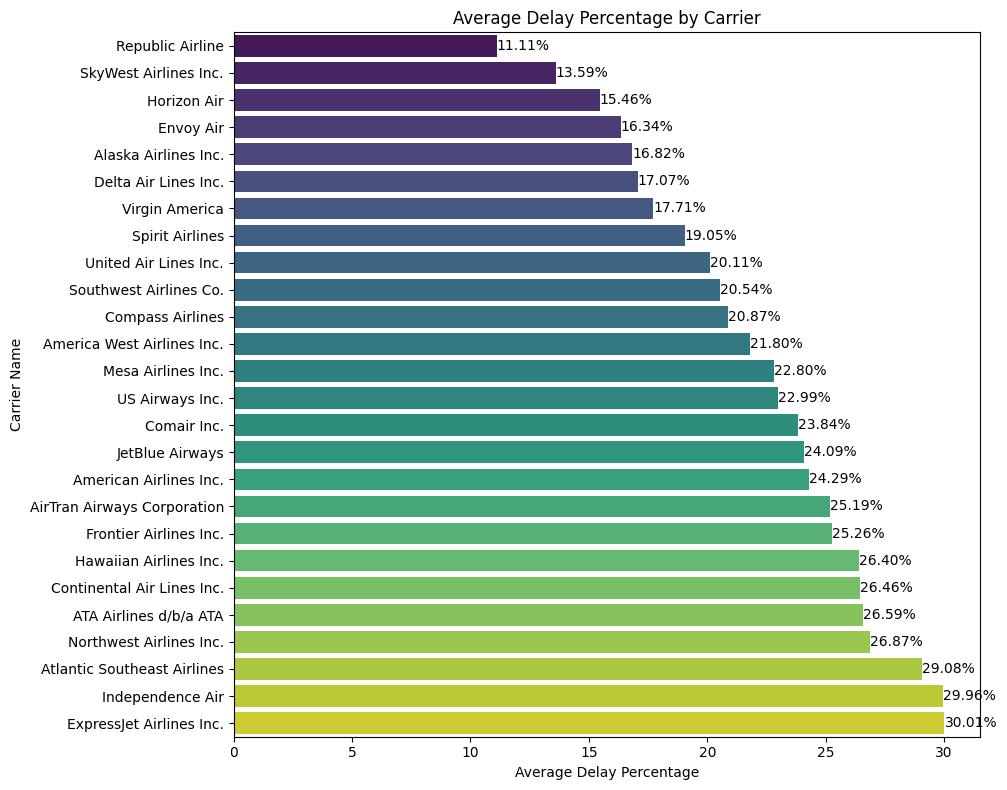

In [ ]:
# Create a bar plot of the average delay percentage by carrier
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=pd.pivot_table(flight_df, index=['carrier_name'],
               values=['delay_percentage'], aggfunc='mean').reset_index(
               ).sort_values('delay_percentage', ascending=True),
                 x='delay_percentage', y='carrier_name',
                 palette='viridis', hue='carrier_name')
plt.title('Average Delay Percentage by Carrier')
plt.xlabel('Average Delay Percentage')
plt.ylabel('Carrier Name')
plt.tight_layout()
# Add percentages on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge')
plt.show()

After looking at this bar graph, it turns out that Alaska Airlines is doing fairly well compared to other airline carriers in terms of average delay percentage.

In [ ]:
# Partition the records into 75% training and 25% test
delay_X = flight_df.loc[:, ['carrier_ct', 'weather_ct', 'nas_ct', 'security_ct',
                            'late_aircraft_ct']]
delay_y = flight_df['delay_percentage']
X_train, X_test, y_train, y_test = train_test_split(delay_X, delay_y,
                                                    test_size=0.25,
                                                    random_state=42)

In [ ]:
# Run a multiple linear regression for delays vs five predictors
model = LinearRegression()
model.fit(X_train, y_train)
np.set_printoptions(precision=9, suppress=True)
print("The model coefficients are:", model.coef_)
print("The model intercept is:", '%.9f' % model.intercept_)

The model coefficients are: [ 0.010264626 -0.05280453   0.000794636 -0.2252606   -0.000080404]
The model intercept is: 21.178704104


In [ ]:
# Evaluate the predictive accuracy of the model by examining its performance on
# the test set using RMSE
y_pred = model.predict(X_test)
mse = np.mean((y_pred - y_test)**2)
rmse = np.sqrt(mse)
print("The root mean squared error is:", '%.4f' % rmse)

y_pred_train = model.predict(X_train)
# Compute residual
e = y_train - y_pred_train
# Compute rmse
rmse_train = np.sqrt( np.mean(e ** 2))
print('Train RMSE:', '%.4f' % rmse_train)

The root mean squared error is: 9.9217
Train RMSE: 10.6261


The RMSE suggests that, on average, the model's predictions for delay percentage are off by about 9.9 percentage points.

Considering the range of delay percentages in the data, this RMSE value seems acceptable, but there might be room for improvement depending on the desired level of precision.

In [ ]:
# Repeat the steps for cancelled and diverted flights
flight_df['cancel_percentage'] = round(flight_df['arr_cancelled'] /
                                      flight_df['arr_flights'], 4) * 100.0
flight_df['diverted_percentage'] = round(flight_df['arr_diverted'] /
                                      flight_df['arr_flights'], 4) * 100.0
flight_df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,month_year,delay_percentage,cancel_percentage,diverted_percentage
0,2025,4,HA,Hawaiian Airlines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",109.0,44.0,41.12,0.07,...,1531.0,1462.0,2.0,0.0,28.0,39.0,2025-04-01,40.37,0.00,0.0
1,2025,4,NK,Spirit Airlines,SEA,"Seattle, WA: Seattle/Tacoma International",62.0,9.0,1.62,0.00,...,701.0,379.0,0.0,76.0,14.0,232.0,2025-04-01,14.52,1.61,0.0
2,2025,4,OO,SkyWest Airlines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",2226.0,245.0,151.53,19.51,...,11529.0,7543.0,892.0,1245.0,0.0,1849.0,2025-04-01,11.01,0.00,0.0
3,2025,4,QX,Horizon Air,SEA,"Seattle, WA: Seattle/Tacoma International",1719.0,254.0,43.80,0.00,...,9997.0,2621.0,0.0,3128.0,0.0,4248.0,2025-04-01,14.78,0.41,0.0
4,2025,4,AA,American Airlines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",450.0,95.0,45.56,7.96,...,6490.0,2670.0,754.0,542.0,0.0,2524.0,2025-04-01,21.11,1.33,0.0


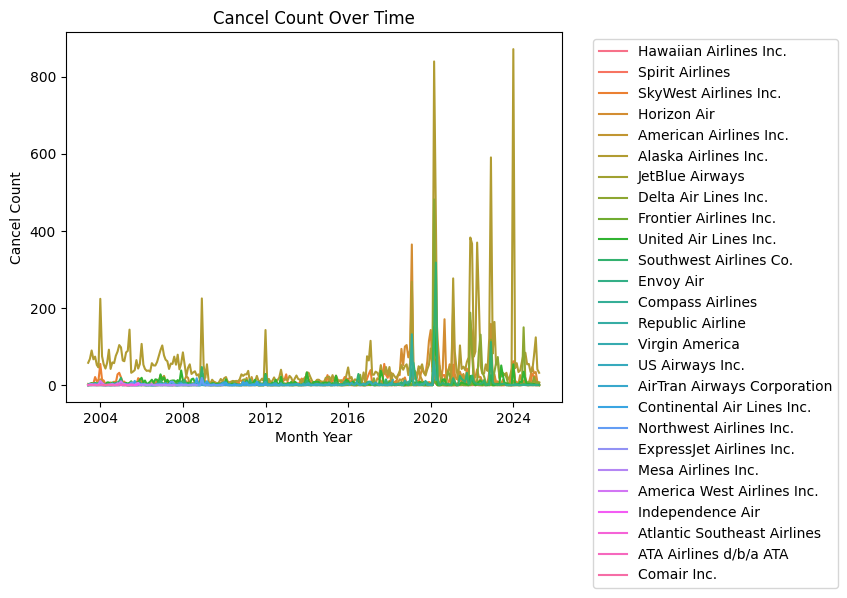

In [ ]:
# Plot cancel count over time
sns.lineplot(data=flight_df, x='month_year', y='arr_cancelled',
             hue = 'carrier_name')
plt.title('Cancel Count Over Time')
plt.xlabel('Month Year')
plt.ylabel('Cancel Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

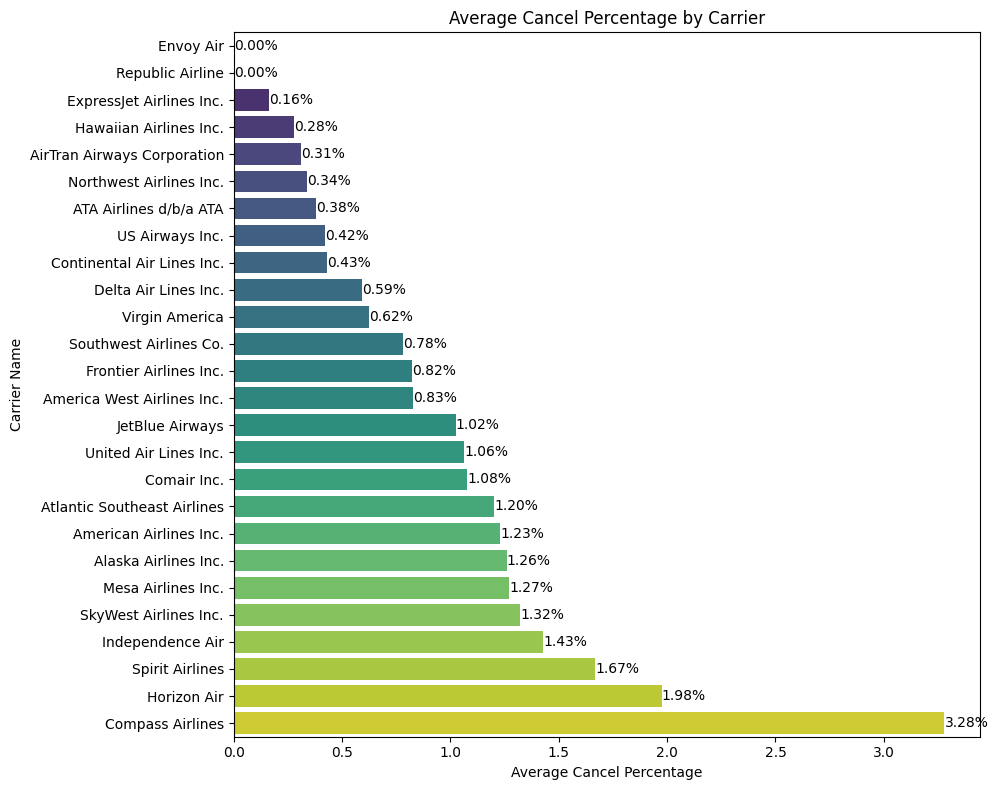

In [ ]:
# Create a bar plot of the average cancellation percentage by carrier
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=pd.pivot_table(flight_df, index=['carrier_name'],
               values=['cancel_percentage'], aggfunc='mean').reset_index(
               ).sort_values('cancel_percentage', ascending=True),
                 x='cancel_percentage', y='carrier_name',
                 palette='viridis', hue='carrier_name')
plt.title('Average Cancel Percentage by Carrier')
plt.xlabel('Average Cancel Percentage')
plt.ylabel('Carrier Name')
plt.tight_layout()
# Add percentages on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge')
plt.show()

In [ ]:
# Partition the records into 75% training and 25% test
cancel_X = flight_df.loc[:, ['carrier_ct', 'weather_ct', 'nas_ct',
                             'security_ct', 'late_aircraft_ct']]
cancel_y = flight_df['cancel_percentage']
X_train2, X_test2, y_train2, y_test2 = train_test_split(cancel_X, cancel_y,
                                                    test_size=0.25,
                                                    random_state=42)

In [ ]:
# Run a multiple linear regression for cancels vs five predictors
model = LinearRegression()
model.fit(X_train2, y_train2)
np.set_printoptions(precision=9, suppress=True)
print("The model coefficients are:", model.coef_)
print("The model intercept is:", '%.9f' % model.intercept_)

The model coefficients are: [-0.003918579  0.046657537 -0.000414535 -0.028258956  0.002515212]
The model intercept is: 0.754381927


In [ ]:
# Evaluate the predictive accuracy of the model by examining its performance on
# the test set using RMSE
y_pred2 = model.predict(X_test2)
mse = np.mean((y_pred2 - y_test2)**2)
rmse = np.sqrt(mse)
print("The root mean squared error is:", '%.4f' % rmse)

y_pred_train2 = model.predict(X_train2)
# Compute residual
e = y_train2 - y_pred_train2
# Compute rmse
rmse_train = np.sqrt( np.mean(e ** 2))
print('Train RMSE:', '%.4f' % rmse_train)

The root mean squared error is: 3.3578
Train RMSE: 2.3228


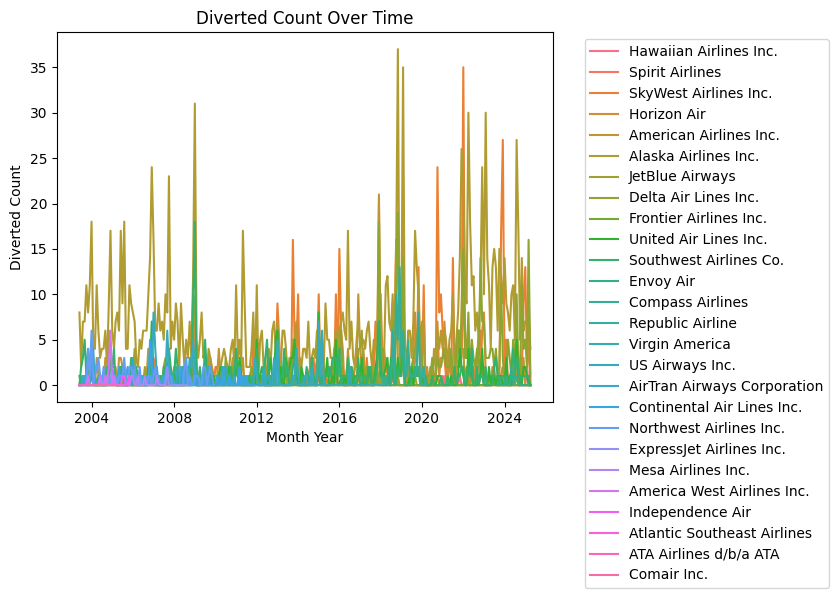

In [ ]:
# Plot diverted count over time
sns.lineplot(data=flight_df, x='month_year', y='arr_diverted',
             hue = 'carrier_name')
plt.title('Diverted Count Over Time')
plt.xlabel('Month Year')
plt.ylabel('Diverted Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

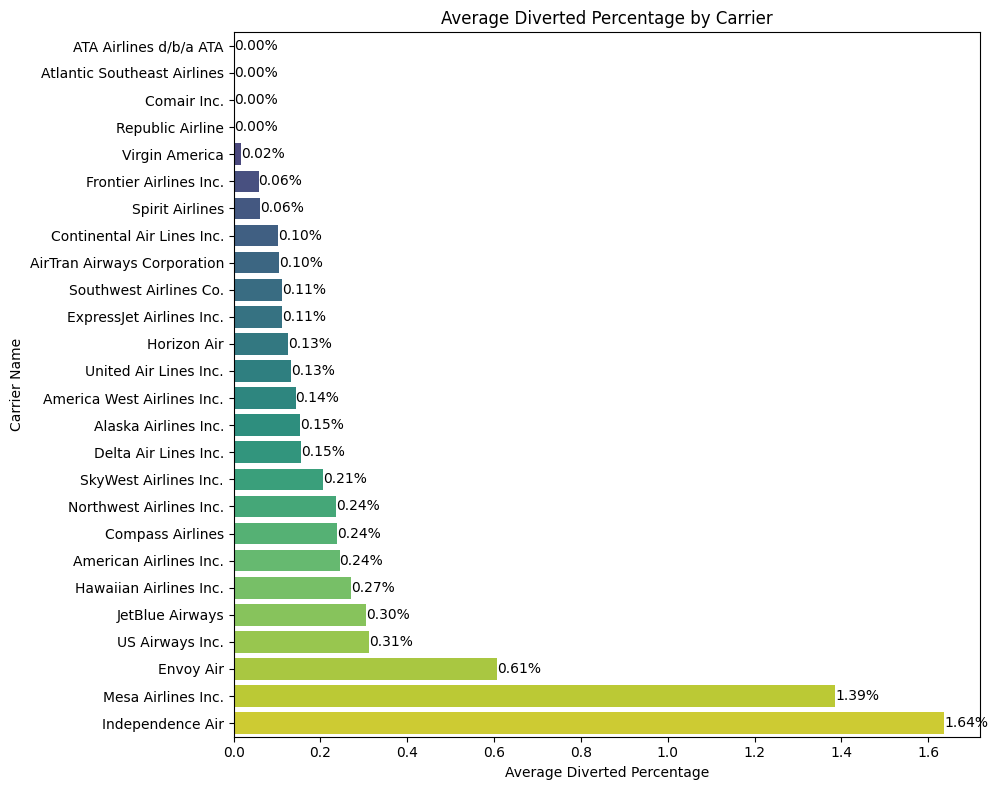

In [ ]:
# Create a bar plot of the average diverted percentage by carrier
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=pd.pivot_table(flight_df, index=['carrier_name'],
               values=['diverted_percentage'], aggfunc='mean').reset_index(
               ).sort_values('diverted_percentage', ascending=True),
                 x='diverted_percentage', y='carrier_name',
                 palette='viridis', hue='carrier_name')
plt.title('Average Diverted Percentage by Carrier')
plt.xlabel('Average Diverted Percentage')
plt.ylabel('Carrier Name')
plt.tight_layout()
# Add percentages on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge')
plt.show()

In [ ]:
# Partition the records into 75% training and 25% test
diverted_X = flight_df.loc[:, ['carrier_ct', 'weather_ct', 'nas_ct',
                             'security_ct', 'late_aircraft_ct']]
diverted_y = flight_df['diverted_percentage']
X_train3, X_test3, y_train3, y_test3 = train_test_split(diverted_X, diverted_y,
                                                    test_size=0.25,
                                                    random_state=42)

In [ ]:
# Run a multiple linear regression for diversions vs five predictors
model = LinearRegression()
model.fit(X_train3, y_train3)
np.set_printoptions(precision=9, suppress=True)
print("The model coefficients are:", model.coef_)
print("The model intercept is:", '%.9f' % model.intercept_)

The model coefficients are: [-0.000899397  0.004237965  0.000168604 -0.000083998 -0.000005262]
The model intercept is: 0.206707192


In [ ]:
# Evaluate the predictive accuracy of the model by examining its performance on
# the test set using RMSE
y_pred3 = model.predict(X_test3)
mse = np.mean((y_pred3 - y_test3)**2)
rmse = np.sqrt(mse)
print("The root mean squared error is:", '%.4f' % rmse)

y_pred_train3 = model.predict(X_train3)
# Compute residual
e = y_train3 - y_pred_train3
# Compute rmse
rmse_train = np.sqrt( np.mean(e ** 2))
print('Train RMSE:', '%.4f' % rmse_train)

The root mean squared error is: 0.3701
Train RMSE: 0.6118


In [ ]:
# Creates a pivot table to show each carrier and the count, want to select
# carriers that has a count of at least 200 months
focus_pivot = pd.pivot_table(flight_df, index=['carrier'],
                             aggfunc='count').reset_index()
focus_pivot = focus_pivot[['carrier', 'airport']]
focus_pivot = focus_pivot.rename(columns={'airport': 'count'})
focus_pivot = focus_pivot[focus_pivot['count'] >= 200].reset_index(drop=True)
focus_pivot

,carrier,count
0,AA,263
1,AS,263
2,B6,263
3,DL,263
4,F9,240
5,HA,256
6,OO,263
7,UA,263
8,WN,263


In [ ]:
# Takes the pivot and turns it into a list, and filters the original dataframe
# to show the carriers that will be focused on with the analysis
focused_carriers = focus_pivot['carrier'].tolist()
focused_flight_df = flight_df[flight_df['carrier'].isin(focused_carriers)]
focused_flight_df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,month_year,delay_percentage,cancel_percentage,diverted_percentage
0,2025,4,HA,Hawaiian Airlines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",109.0,44.0,41.12,0.07,...,1531.0,1462.0,2.0,0.0,28.0,39.0,2025-04-01,40.37,0.00,0.00
2,2025,4,OO,SkyWest Airlines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",2226.0,245.0,151.53,19.51,...,11529.0,7543.0,892.0,1245.0,0.0,1849.0,2025-04-01,11.01,0.00,0.00
4,2025,4,AA,American Airlines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",450.0,95.0,45.56,7.96,...,6490.0,2670.0,754.0,542.0,0.0,2524.0,2025-04-01,21.11,1.33,0.00
5,2025,4,AS,Alaska Airlines Inc.,SEA,"Seattle, WA: Seattle/Tacoma International",5840.0,1119.0,232.04,21.87,...,56280.0,16292.0,1068.0,12563.0,317.0,26040.0,2025-04-01,19.16,0.55,0.07
6,2025,4,B6,JetBlue Airways,SEA,"Seattle, WA: Seattle/Tacoma International",31.0,6.0,1.47,0.00,...,194.0,28.0,0.0,57.0,0.0,109.0,2025-04-01,19.35,0.00,0.00


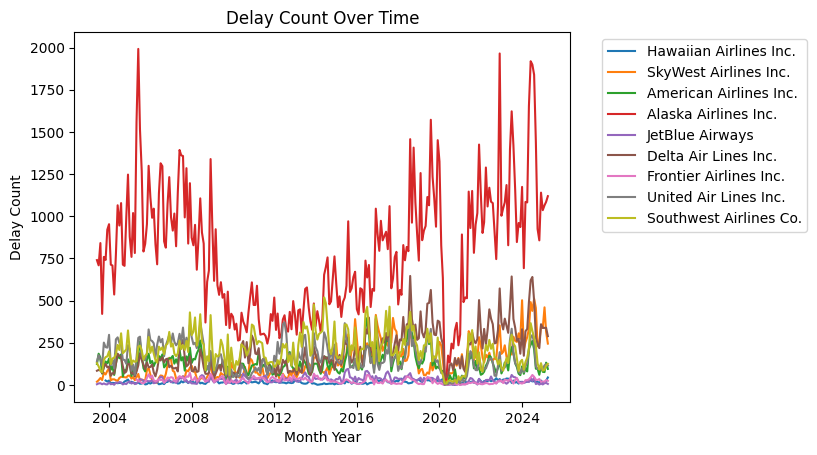

In [ ]:
# Plot delay count over time
sns.lineplot(data=focused_flight_df, x='month_year', y='arr_del15',
             hue = 'carrier_name')
plt.title('Delay Count Over Time')
plt.xlabel('Month Year')
plt.ylabel('Delay Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

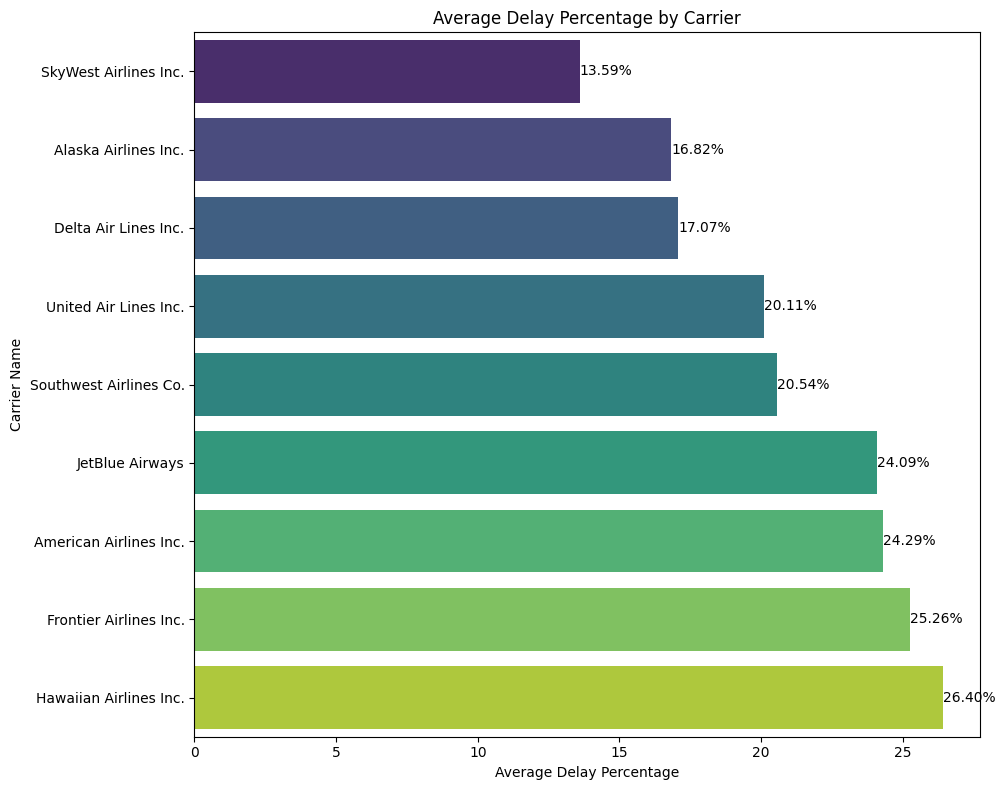

In [ ]:
# Create a bar plot of the average delay percentage by carrier
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=pd.pivot_table(focused_flight_df, index=['carrier_name'],
               values=['delay_percentage'], aggfunc='mean').reset_index(
               ).sort_values('delay_percentage', ascending=True),
                 x='delay_percentage', y='carrier_name',
                 palette='viridis', hue='carrier_name')
plt.title('Average Delay Percentage by Carrier')
plt.xlabel('Average Delay Percentage')
plt.ylabel('Carrier Name')
plt.tight_layout()
# Add percentages on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge')
plt.show()

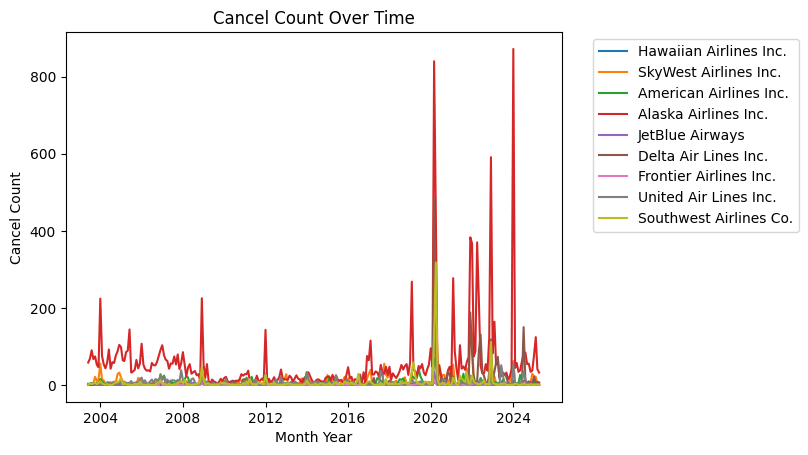

In [ ]:
# Plot cancel count over time
sns.lineplot(data=focused_flight_df, x='month_year', y='arr_cancelled',
             hue = 'carrier_name')
plt.title('Cancel Count Over Time')
plt.xlabel('Month Year')
plt.ylabel('Cancel Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

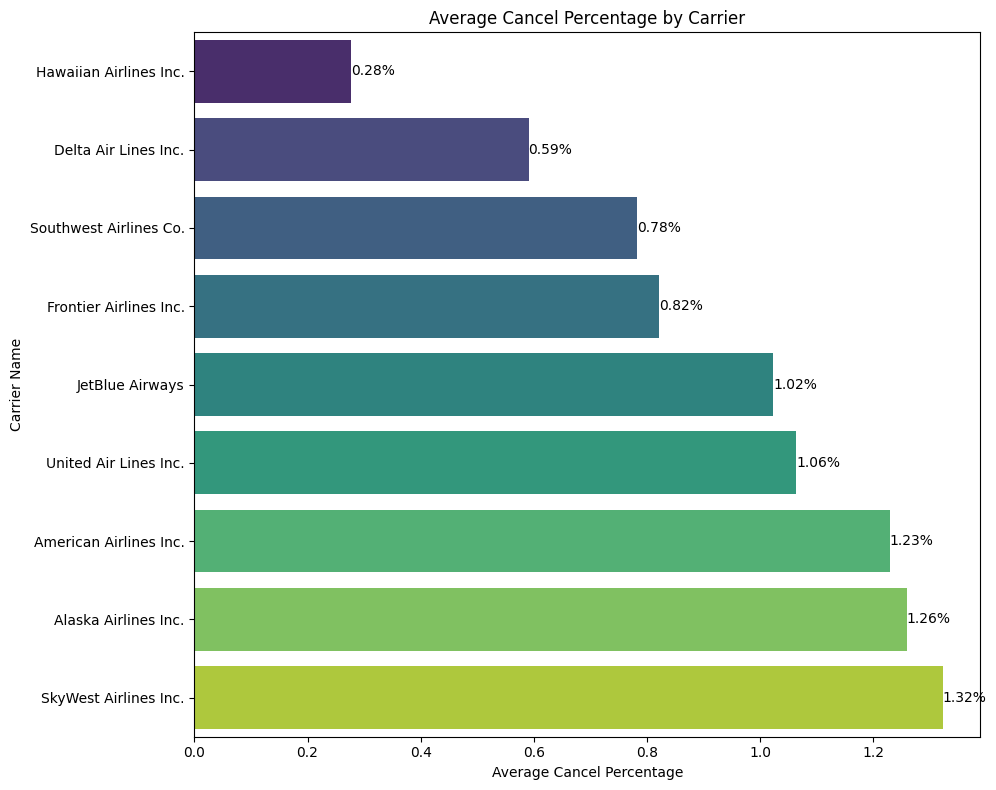

In [ ]:
# Create a bar plot of the average cancellation percentage by carrier
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=pd.pivot_table(focused_flight_df, index=['carrier_name'],
               values=['cancel_percentage'], aggfunc='mean').reset_index(
               ).sort_values('cancel_percentage', ascending=True),
                 x='cancel_percentage', y='carrier_name',
                 palette='viridis', hue='carrier_name')
plt.title('Average Cancel Percentage by Carrier')
plt.xlabel('Average Cancel Percentage')
plt.ylabel('Carrier Name')
plt.tight_layout()
# Add percentages on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge')
plt.show()

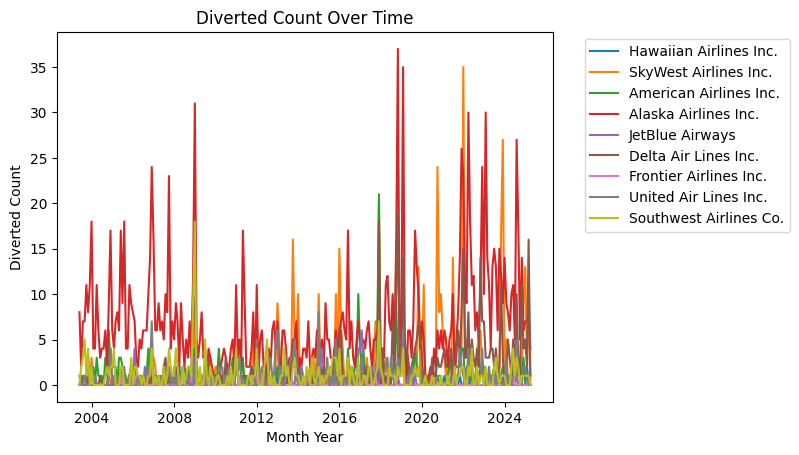

In [ ]:
# Plot diverted count over time
sns.lineplot(data=focused_flight_df, x='month_year', y='arr_diverted',
             hue = 'carrier_name')
plt.title('Diverted Count Over Time')
plt.xlabel('Month Year')
plt.ylabel('Diverted Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

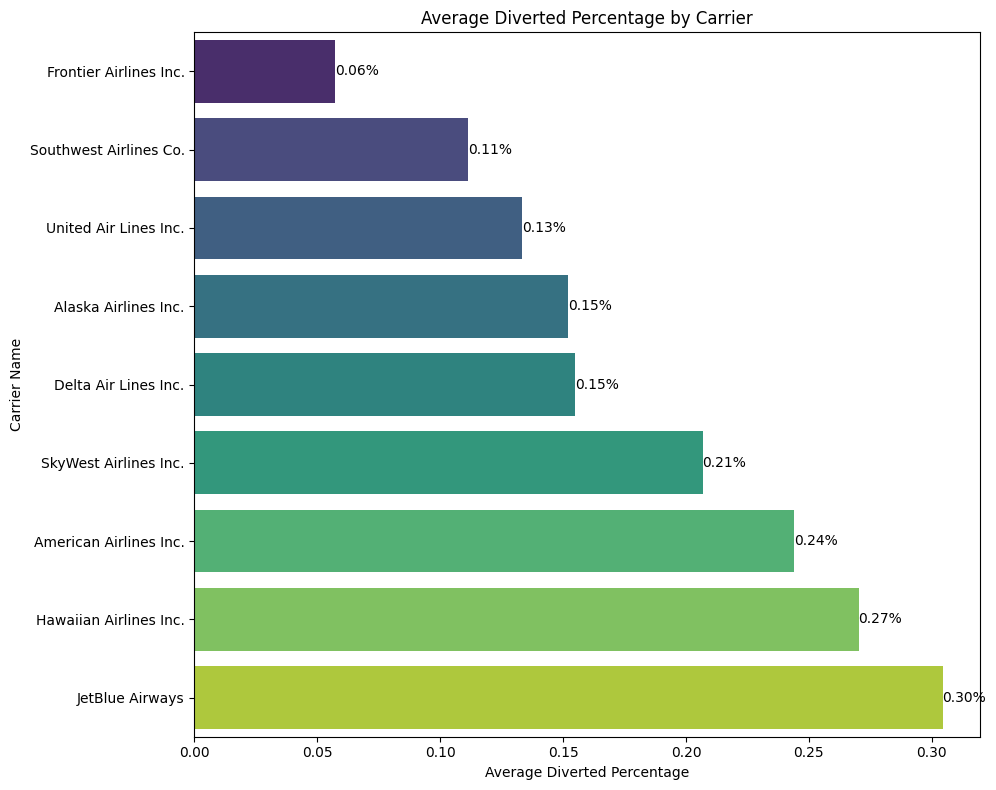

In [ ]:
# Create a bar plot of the average diverted percentage by carrier
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=pd.pivot_table(focused_flight_df, index=['carrier_name'],
               values=['diverted_percentage'], aggfunc='mean').reset_index(
               ).sort_values('diverted_percentage', ascending=True),
                 x='diverted_percentage', y='carrier_name',
                 palette='viridis', hue='carrier_name')
plt.title('Average Diverted Percentage by Carrier')
plt.xlabel('Average Diverted Percentage')
plt.ylabel('Carrier Name')
plt.tight_layout()
# Add percentages on each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', label_type='edge')
plt.show()